In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [ ]:

from typing import TypedDict, List

class AgentState(TypedDict):
    name: str
    age: int
    skills: List[str]
    result: str


#first node

def greeting(state: AgentState) -> AgentState:

    state["result"] = f"Hi {state["name"]}, Nice to have you!."

    return state


#second node -> user age

def age_node(state: AgentState) -> AgentState:

    state["result"] = state["result"] + f"your are {state["age"]} years old."

    return state


def skills_node(state: AgentState) -> AgentState:

    skills_string = ",".join(state["skills"])

    state["result"] = state["result"] + f"you have skills in: {skills_string}."

    return state

In [5]:
graph = StateGraph(AgentState)

graph.add_node("age_node", age_node)
graph.add_node("greeting_node", greeting)
graph.add_node("skills_node", skills_node)

graph.add_edge(START, "greeting_node")
graph.add_edge("greeting_node", "age_node")
graph.add_edge("age_node", "skills_node")
graph.add_edge("skills_node", END)

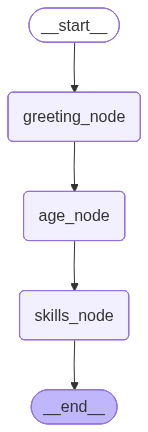

In [7]:
graph.compile()

In [8]:
app = graph.compile()

In [9]:
app.invoke({"name": "Babar", "age": 25, "skills": ["python", "pytorch"]})

{'name': 'Babar',
 'age': 25,
 'skills': ['python', 'pytorch'],
 'result': 'Hi Babar, Nice to have you!.your are 25 years old.you have skills in: python,pytorch.'}